In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("norwegian_stocks.csv")

print(df.head())


         Date  AKER BP  DNB BANK    EQUINOR  GJENSIDIGE FORSIKR  \
0  2025-01-08    243.3     229.2  284.32814           203.36380   
1  2025-01-09    245.2     228.5  284.82073           208.14414   
2  2025-01-10    252.2     229.4  289.74672           204.35971   
3  2025-01-13    256.1     232.1  293.68752           205.35561   
4  2025-01-14    255.4     233.8  286.39705           206.94906   

   HAFNIA LIMITED  HÖEGH AUTOLINERS  KONGSBERG GRUPPEN    MOWI    NEL  \
0           63.00             112.8              261.6  193.50  2.865   
1           62.95             110.0              252.2  197.15  3.013   
2           67.50             114.5              249.4  195.20  2.825   
3           69.15             112.3              243.8  193.55  2.101   
4           69.15             110.0              246.8  197.30  2.266   

   NORSK HYDRO      ORKLA  REACH SUBSEA  TELENOR  YARA INTERNATIONAL  
0        62.68  93.841176          7.50    127.8               307.1  
1        64.48  

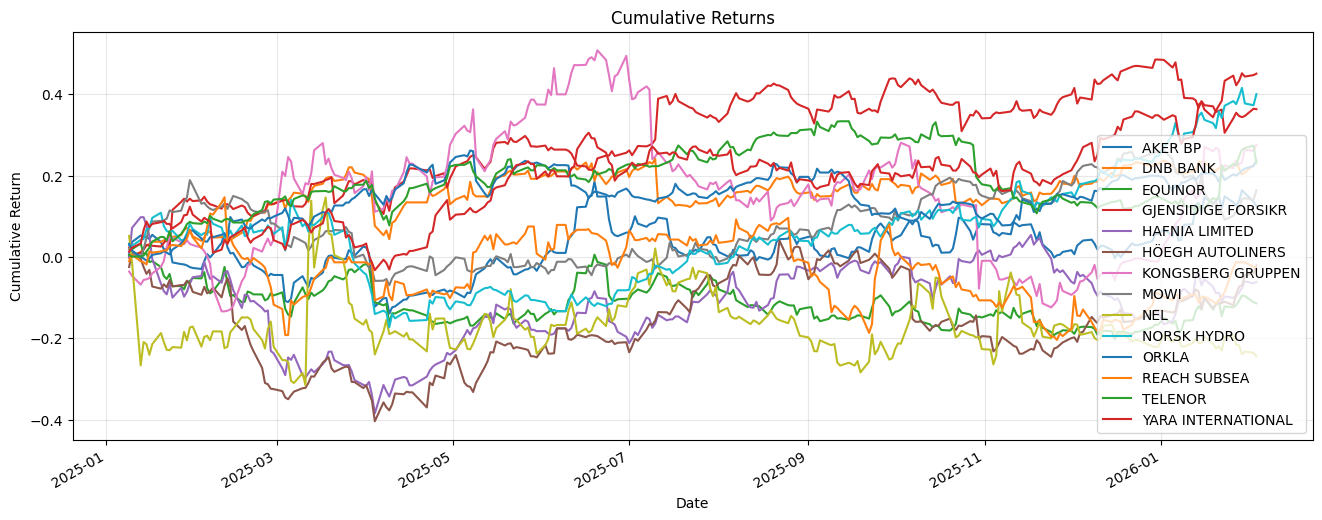

In [3]:
# Make sure Date is datetime and sorted
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Calculate daily returns
daily_returns = df.pct_change()

# Calculate cumulative returns
cumulative_returns = (1 + daily_returns).cumprod() - 1

# Plot cumulative returns
cumulative_returns.plot(figsize=(16, 6))
plt.title("Cumulative Returns")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()




In [4]:
stocks = df.columns.tolist()
print(stocks)

['AKER BP', 'DNB BANK', 'EQUINOR', 'GJENSIDIGE FORSIKR', 'HAFNIA LIMITED', 'HÖEGH AUTOLINERS', 'KONGSBERG GRUPPEN', 'MOWI', 'NEL', 'NORSK HYDRO', 'ORKLA', 'REACH SUBSEA', 'TELENOR', 'YARA INTERNATIONAL']


In [5]:
num_rows = df.shape[0]
print(f"The number of rows is: {num_rows}")

The number of rows is: 274


In [6]:
log_returns = np.log(1 + daily_returns)
returns = log_returns.dropna()

print(returns.head())


             AKER BP  DNB BANK   EQUINOR  GJENSIDIGE FORSIKR  HAFNIA LIMITED  \
Date                                                                           
2025-01-09  0.007779 -0.003059  0.001731            0.023234       -0.000794   
2025-01-10  0.028148  0.003931  0.017147           -0.018349        0.069787   
2025-01-13  0.015346  0.011701  0.013509            0.004861        0.024150   
2025-01-14 -0.002737  0.007298 -0.025137            0.007730        0.000000   
2025-01-15 -0.000392  0.008094  0.001719            0.011483       -0.018979   

            HÖEGH AUTOLINERS  KONGSBERG GRUPPEN      MOWI       NEL  \
Date                                                                  
2025-01-09         -0.025136          -0.036594  0.018687  0.050368   
2025-01-10          0.040094          -0.011164 -0.009940 -0.064428   
2025-01-13         -0.019401          -0.022710 -0.008489 -0.296095   
2025-01-14         -0.020693           0.012230  0.019190  0.075603   
2025-01-15   

In [7]:
rf = 0.03  # Risk-free rate

rf_daily = rf / 252
excess_returns = returns - rf_daily

mean_return_annual = excess_returns.mean() * 252
cov_matrix_annual = excess_returns.cov() * 252
vol_annual = np.sqrt(np.diag(cov_matrix_annual)) # variance on the diagonal

sharpe = mean_return_annual / vol_annual


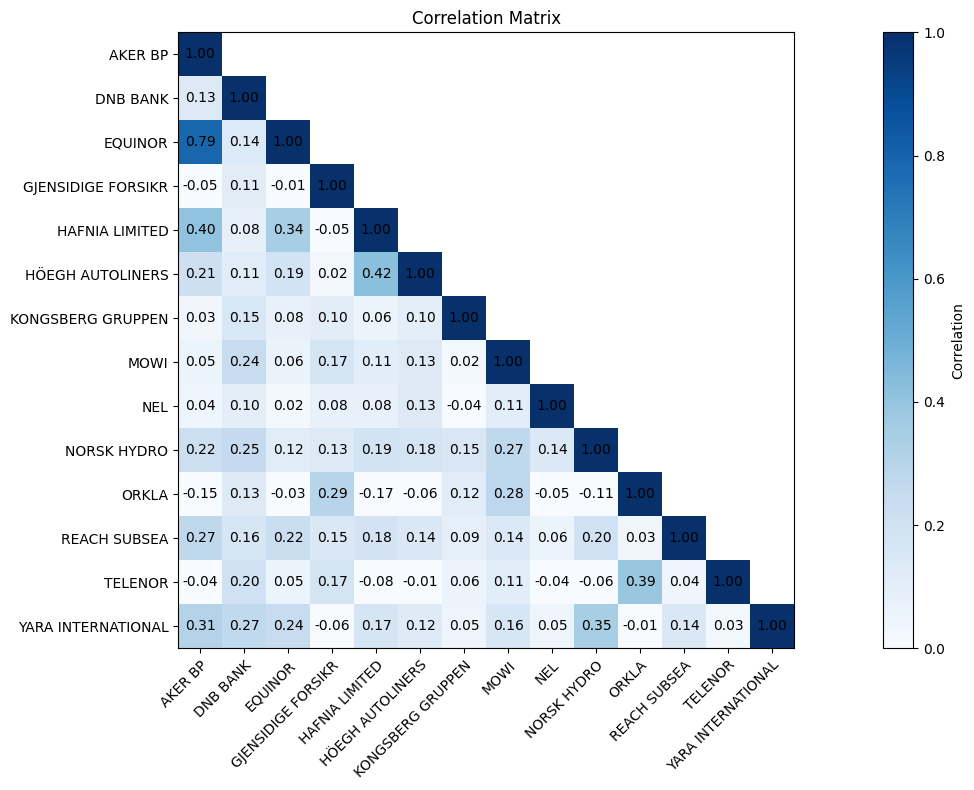

In [8]:
# correlation matrix
corr_matrix = returns.corr()
labels = corr_matrix.columns

# mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k = 1)

fig, ax = plt.subplots(figsize=(18, 8))

# plot lower triangle
im = ax.imshow(corr_matrix.values, cmap="Blues", vmin=0, vmax=1)
im.set_data(np.ma.array(corr_matrix.values, mask=mask))

# ticks and labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# annotate values
for i in range(len(labels)):
    for j in range(len(labels)):
        if not mask[i, j]:
            ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                    ha="center", va="center")

# colorbar from 0 to 1
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation")

ax.set_title("Correlation Matrix")
fig.tight_layout()
plt.show()


In [9]:
lookbacks = {
    '1M': 21,
    '3M': 63,
    '6M': 126,
    '1Y (12–1)': 252,
}

momentum = pd.DataFrame(index=stocks)

for label, days in lookbacks.items():
    if label == '1Y (12–1)':
        # exclude most recent month
        momentum[label] = df[stocks].iloc[-21] / df[stocks].iloc[-days] - 1
    else:
        momentum[label] = df[stocks].iloc[-1] / df[stocks].iloc[-days] - 1

# full-period momentum
momentum['All'] = df[stocks].iloc[-1] / df[stocks].iloc[0] - 1

momentum *= 100

print(momentum)


                           1M         3M         6M  1Y (12–1)        All
AKER BP              4.306402   6.085271  11.805556   7.102041  12.494862
DNB BANK             1.612903   8.206107   6.739458  16.201583  23.691099
EQUINOR              5.177453   3.619910  -0.865801  -7.986998 -11.405181
GJENSIDIGE FORSIKR  -7.784431   0.946832  -2.805049  31.119036  36.307445
HAFNIA LIMITED       9.154670  -5.345711   1.406036  -9.700000  -6.126984
HÖEGH AUTOLINERS    13.101331  27.598152   0.090580  -6.327900  -2.039007
KONGSBERG GRUPPEN   18.004952  30.210773  11.946309  17.011589  27.522936
MOWI                -3.595890   1.716350  12.995484   8.248378  16.382429
NEL                 -5.502183   2.656546 -10.946502  -2.178556 -24.467714
NORSK HYDRO          5.303576  30.246364  38.335435  22.956624  40.012763
ORKLA                5.163043  11.957570   5.545455  12.200080  23.719677
REACH SUBSEA         7.352941   9.609610 -10.866911 -17.874396  -2.666667
TELENOR              8.189952   5.7873

In [10]:
mom = momentum['1Y (12–1)'] / 100   # convert from percent to decimal

sharpe_z = (sharpe - sharpe.mean()) / sharpe.std()

mom_z = (mom - mom.mean()) / mom.std()

score = 0.4 * sharpe_z + 0.6 * mom_z
score = score.sort_values(ascending=False)

print(score)



YARA INTERNATIONAL    1.575608
GJENSIDIGE FORSIKR    1.372509
NORSK HYDRO           1.010701
DNB BANK              0.563776
ORKLA                 0.489124
KONGSBERG GRUPPEN     0.362408
TELENOR               0.143043
MOWI                  0.078714
AKER BP              -0.117689
HÖEGH AUTOLINERS     -0.898252
NEL                  -0.905978
HAFNIA LIMITED       -1.099453
EQUINOR              -1.220754
REACH SUBSEA         -1.353759
dtype: float64
